 INPUT (from Tinkercad / manual)



Bin Details:
Bin1: 80.33%
Bin2: 50.0%
Bin3: 16.67%
Bin4: 66.67%

Route:
Depot -> Bin1 -> Bin4 -> Bin2 -> Bin3 -> WasteCenter


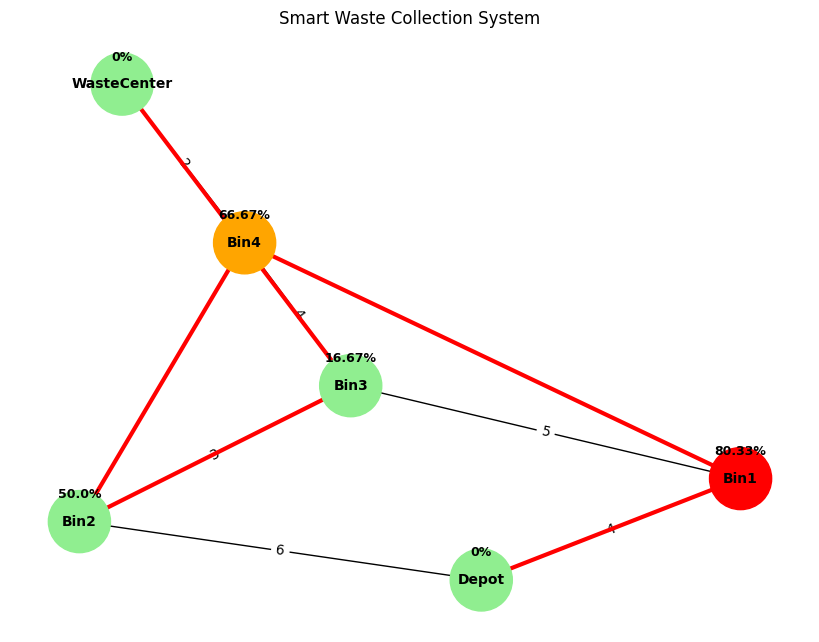

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
# INPUT (from Tinkercad / manual)
bins = {
    "Bin1": 5.9,
    "Bin2": 15,
    "Bin3": 25,
    "Bin4": 10
}
# PROCESS (Fill %)
fill_data = {b: round(((30-d)/30)*100,2) for b,d in bins.items()}
fill_data["Depot"] = 0
fill_data["WasteCenter"] = 0

# DECISION (Route)
sorted_bins = sorted(bins, key=lambda x: fill_data[x], reverse=True)
route = ["Depot"] + sorted_bins + ["WasteCenter"]

# GRAPH
G = nx.Graph()

edges = [
("Depot","Bin1",4),
("Depot","Bin2",6),
("Bin1","Bin3",5),
("Bin2","Bin3",3),
("Bin3","Bin4",4),
("Bin4","WasteCenter",2)
]

G.add_weighted_edges_from(edges)
pos = nx.spring_layout(G, seed=42)
# COLORS
colors = []
for node in G.nodes():
    f = fill_data.get(node,0)
    if f > 80:
        colors.append("red")
    elif f > 50:
        colors.append("orange")
    else:
        colors.append("lightgreen")

# OUTPUT
print("Bin Details:")
for b in bins:
    print(f"{b}: {fill_data[b]}%")

print("\nRoute:")
print(" -> ".join(route))

# DRAW
plt.figure(figsize=(8,6))

nx.draw(G, pos,
        with_labels=True,
        node_color=colors,
        node_size=2000,
        font_size=10,
        font_weight='bold')

# edge weights
labels = nx.get_edge_attributes(G,'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

# show % on nodes
for node, (x, y) in pos.items():
    plt.text(x, y+0.08,
             f"{fill_data.get(node,0)}%",
             ha='center',
             fontsize=9,
             fontweight='bold')

# highlight route
path = list(zip(route, route[1:]))
nx.draw_networkx_edges(G, pos,
                       edgelist=path,
                       edge_color='red',
                       width=3)

plt.title("Smart Waste Collection System")
plt.show()

Using dynamic simulation


--- BIN DETAILS ---
Bin1: Distance=30 cm | Fill=0.0%
Bin2: Distance=10 cm | Fill=66.67%
Bin3: Distance=16 cm | Fill=46.67%
Bin4: Distance=17 cm | Fill=43.33%

--- ROUTE ---
Depot -> Bin2 -> Bin3 -> Bin4 -> Bin1 -> WasteCenter


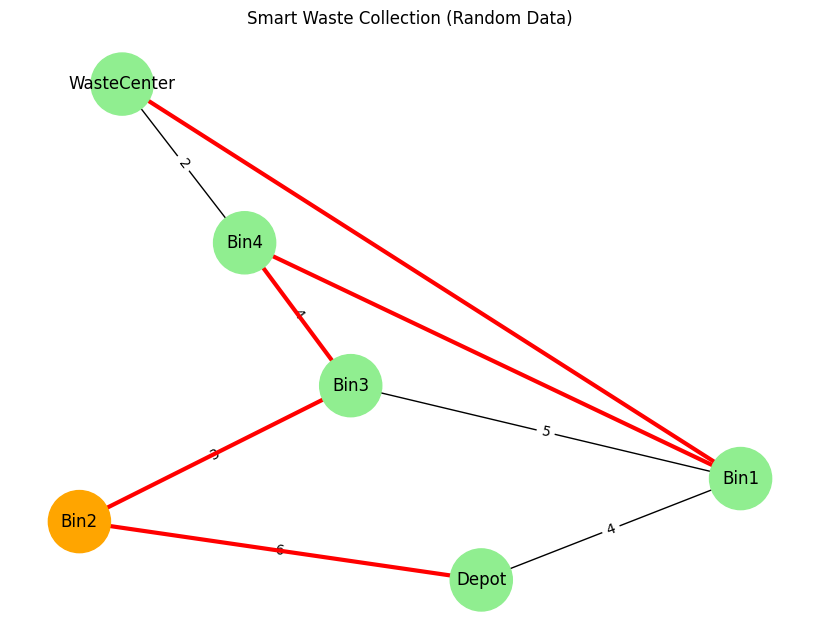

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import random

# GRAPH SETUP
G = nx.Graph()

edges = [
("Depot","Bin1",4), ("Depot","Bin2",6),
("Bin1","Bin3",5), ("Bin2","Bin3",3),
("Bin3","Bin4",4), ("Bin4","WasteCenter",2)
]

for u,v,w in edges:
    G.add_edge(u,v,weight=w)

pos = nx.spring_layout(G, seed=42)

# RANDOM BIN DATA
bins = {
    "Bin1": random.randint(5,30),
    "Bin2": random.randint(5,30),
    "Bin3": random.randint(5,30),
    "Bin4": random.randint(5,30)
}

# FILL %

fill_data = {}

for b,d in bins.items():
    fill_data[b] = round(((30-d)/30)*100,2)

fill_data["Depot"] = 0
fill_data["WasteCenter"] = 0

# SORT ROUTE

sorted_bins = sorted(bins, key=lambda x: fill_data[x], reverse=True)

route = ["Depot"] + sorted_bins + ["WasteCenter"]

# PRINT OUTPUT

print("\n--- BIN DETAILS ---")
for b in bins:
    print(f"{b}: Distance={bins[b]} cm | Fill={fill_data[b]}%")

print("\n--- ROUTE ---")
print(" -> ".join(route))


# COLORS

colors = []

for node in G.nodes():
    f = fill_data.get(node,0)

    if f > 80:
        colors.append("red")
    elif f > 50:
        colors.append("orange")
    else:
        colors.append("lightgreen")
# DRAW GRAPH
plt.figure(figsize=(8,6))

nx.draw(G, pos,
        with_labels=True,
        node_color=colors,
        node_size=2000)

labels = nx.get_edge_attributes(G,'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

# highlight route
path = list(zip(route, route[1:]))

nx.draw_networkx_edges(G, pos,
                       edgelist=path,
                       edge_color='red',
                       width=3)

plt.title("Smart Waste Collection (Random Data)")
plt.show()

smart waste collection system with multi-truck


🔄 LIVE UPDATE 1
Bin1: 40.0%
Bin2: 6.67%
Bin3: 66.67%
Bin4: 83.33%
Bin5: 20.0%
Bin6: 33.33%
Truck1: Depot -> Bin4 -> Bin3 -> Bin1 -> WasteCenter
Truck2: Depot -> Bin6 -> Bin5 -> Bin2 -> WasteCenter


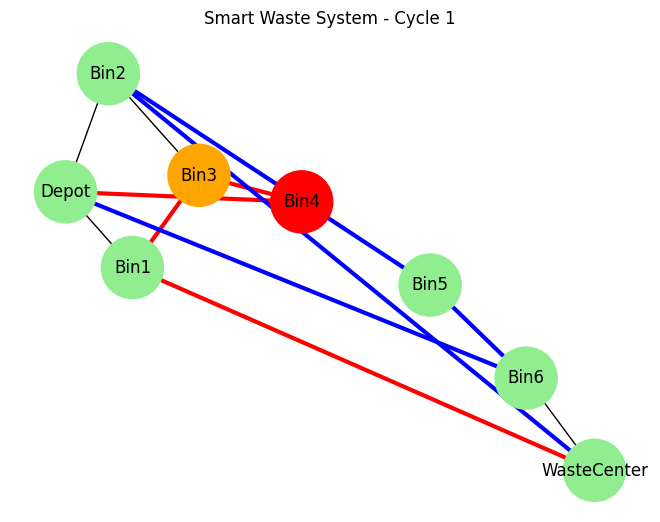


🔄 LIVE UPDATE 2
Bin1: 50.0%
Bin2: 76.67%
Bin3: 3.33%
Bin4: 20.0%
Bin5: 63.33%
Bin6: 73.33%
Truck1: Depot -> Bin2 -> Bin6 -> Bin5 -> WasteCenter
Truck2: Depot -> Bin1 -> Bin4 -> Bin3 -> WasteCenter


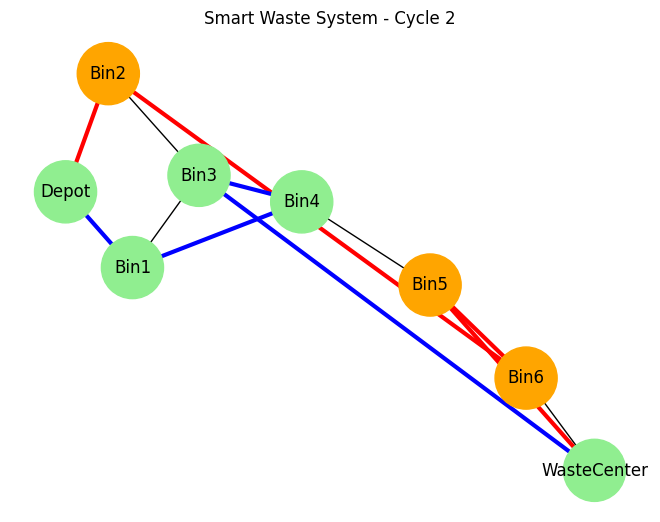


🔄 LIVE UPDATE 3
Bin1: 83.33%
Bin2: 13.33%
Bin3: 10.0%
Bin4: 23.33%
Bin5: 10.0%
Bin6: 0.0%
Truck1: Depot -> Bin1 -> Bin4 -> Bin2 -> WasteCenter
Truck2: Depot -> Bin3 -> Bin5 -> Bin6 -> WasteCenter


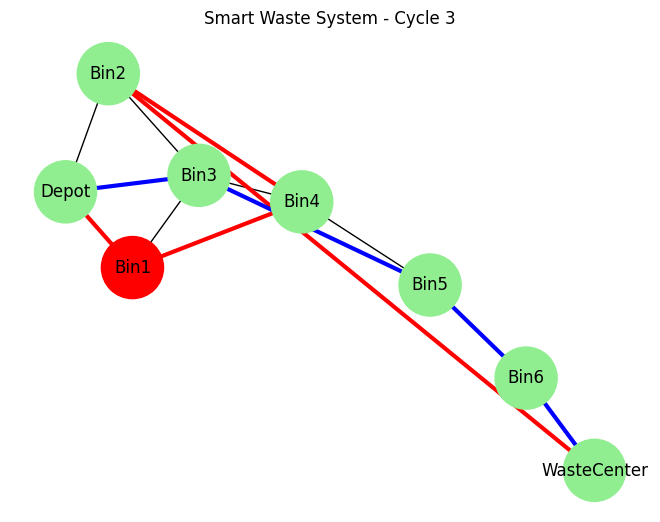

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import time

# CREATE GRAPH
G = nx.Graph()

edges = [
("Depot","Bin1",4), ("Depot","Bin2",6),
("Bin1","Bin3",5), ("Bin2","Bin3",3),
("Bin3","Bin4",4), ("Bin4","Bin5",2),
("Bin5","Bin6",3), ("Bin6","WasteCenter",4)
]

for u,v,w in edges:
    G.add_edge(u,v,weight=w)

pos = nx.spring_layout(G, seed=42)

# REAL-TIME LOOP
for cycle in range(3):

    plt.clf()
    print(f"\n🔄 LIVE UPDATE {cycle+1}")

    # SIMULATE BINS
    bins = {f"Bin{i}": random.randint(5,30) for i in range(1,7)}

    # FILL %
    fill_data = {}
    for b,d in bins.items():
        fill_data[b] = round(((30-d)/30)*100,2)

    fill_data["Depot"] = 0
    fill_data["WasteCenter"] = 0

    # SORT BY PRIORITY
    sorted_bins = sorted(bins, key=lambda x: fill_data[x], reverse=True)

    # MULTI TRUCK
    mid = len(sorted_bins)//2
    route1 = ["Depot"] + sorted_bins[:mid] + ["WasteCenter"]
    route2 = ["Depot"] + sorted_bins[mid:] + ["WasteCenter"]

    # PRINT
    for b in bins:
        print(f"{b}: {fill_data[b]}%")

    print("Truck1:", " -> ".join(route1))
    print("Truck2:", " -> ".join(route2))

    # ALERT
    for b in bins:
        if fill_data[b] > 90:
            print(f"🚨 ALERT: {b} FULL!")

    # COLORS
    colors = []
    for node in G.nodes():
        f = fill_data.get(node,0)
        if f > 80:
            colors.append("red")
        elif f > 50:
            colors.append("orange")
        else:
            colors.append("lightgreen")

    # DRAW GRAPH
    nx.draw(G, pos,
            with_labels=True,
            node_color=colors,
            node_size=2000)

    # ROUTES
    path1 = list(zip(route1, route1[1:]))
    path2 = list(zip(route2, route2[1:]))

    nx.draw_networkx_edges(G, pos, edgelist=path1, edge_color='red', width=3)
    nx.draw_networkx_edges(G, pos, edgelist=path2, edge_color='blue', width=3)

    plt.title(f"Smart Waste System - Cycle {cycle+1}")
    plt.pause(2)

plt.show()